# Experimentos completos — CPCV vs WF vs KFold

**24 reales** (4 activos × 2 timelines × 3 métodos → aquí 1 experimento/row por activo × timeline)
**60 sintéticos** (20 escenarios × 3 métodos → 1 experimento/row por escenario)

Métricas de evaluación por experimento:
- **delta** = μ(val_SRs) − SR_holdout
- **bias** = delta / |SR_holdout|
- **z_score** = (SR_holdout − μ(val_SRs)) / σ(val_SRs)  ← solo meaningful para CPCV (n=15)

Plots por experimento:
1. Violin OOS por split/fold (CPCV 15 pts, WF 3 pts, KFold 3 pts)
2. Distribución paths CPCV + WF/KFold punto único + línea hold-out

Plot global (una sola vez): split-matrix CPCV 6,2

Salidas en `resultados/real/<timeline>/<ticker>/` y `resultados/synthetic/<scenario>/`

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display
from xgboost import XGBClassifier

from cpcv_analysis.config import (
    XGB_PARAMS, ASSETS, TIMELINES, SYNTHETIC_SCENARIOS, TIMELINE_B, N_GROUPS, K_TEST
)
from cpcv_analysis.experiment import run_experiment_full, run_experiment_full_from_arrays
from cpcv_analysis.synthetic import generate_synthetic_prices
from cpcv_analysis.data import build_features
from cpcv_analysis.plots import (
    plot_split_matrix,
    plot_fold_oos_violins,
    plot_paths_vs_holdout,
)
from cpcv_analysis.splitters import CombinatorialPurgedKFold
from cpcv_analysis.data import load_asset
from cpcv_analysis.backtest_engine import slice_by_dates

clf_template = XGBClassifier(**XGB_PARAMS)
ASSET_TICKERS = list(ASSETS.keys())

# ── Directorios de salida ─────────────────────────────────────────────────────
os.makedirs('resultados', exist_ok=True)
for tl in TIMELINES:
    for ticker in ASSET_TICKERS:
        os.makedirs(f"resultados/real/{tl['name']}/{ticker}", exist_ok=True)
for sc in SYNTHETIC_SCENARIOS:
    os.makedirs(f"resultados/synthetic/{sc['id']}_{sc['name']}", exist_ok=True)

print(f'Activos: {ASSET_TICKERS}')
print(f'Timelines: {[t["name"] for t in TIMELINES]}')
print('Directorios listos.')

Activos: ['SPY', 'AAPL', 'MSTR', 'BTC-USD']
Timelines: ['2023-2026', 'COVID-2017-2020']
Directorios listos.


## Split matrix CPCV 6,2 (una sola vez)
Muestra qué grupos actúan como test en cada uno de los 15 splits.

[data] Loaded SPY prices from cache → /Users/jeronimo.deli/Desktop/other/Vs/TSP/CPCV_tesis/cpcv_analysis/../data_cache/SPY_2023-05-01_2026-01-01.csv
[data] Observations: 646  |  Class balance: 64.1% up
[data] Feature shape: (646, 6)  |  Date range: 2023-05-30 → 2025-12-23
[plots] Saved → resultados/02_split_matrix.png


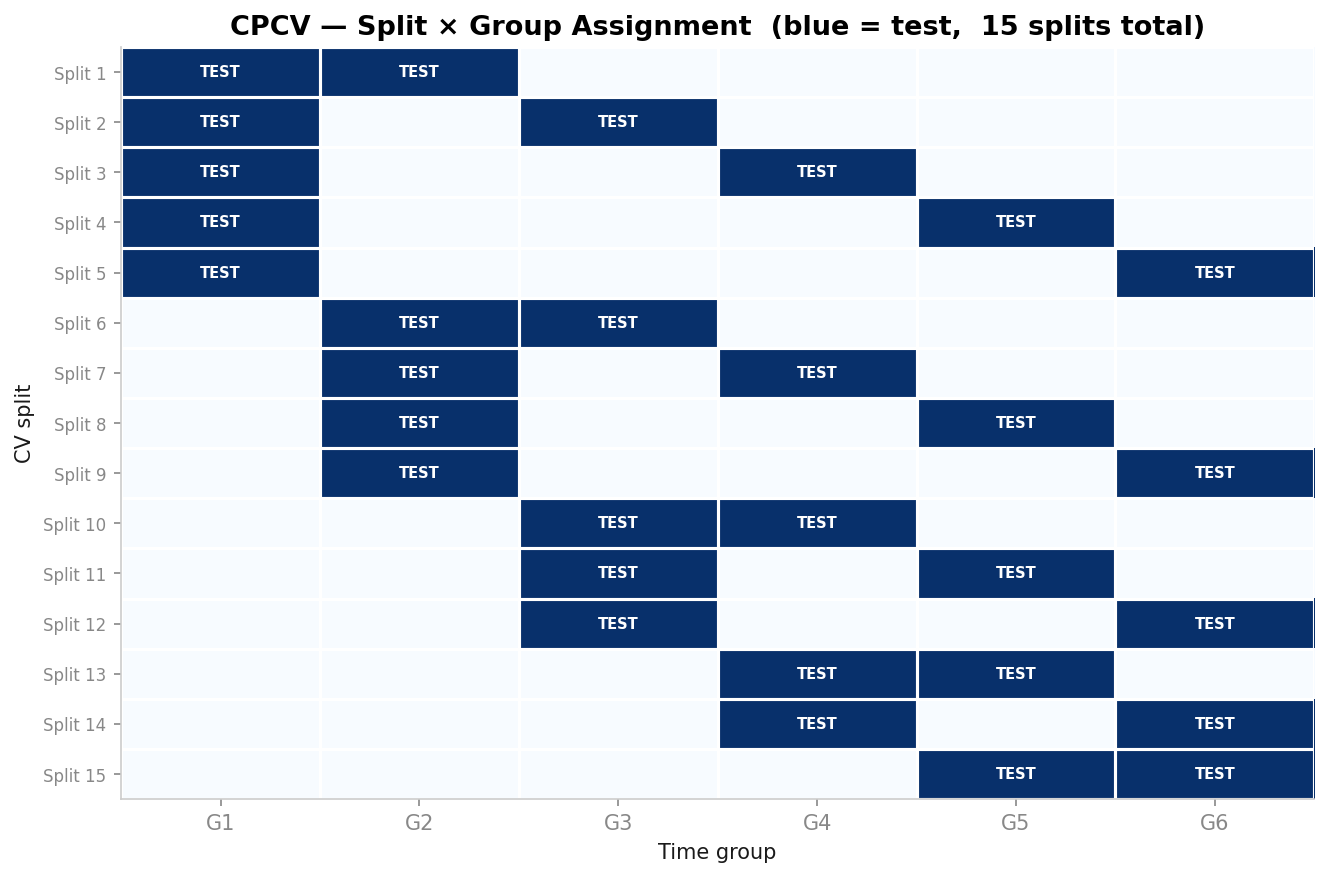

In [2]:
# Construir tabla de splits para cualquier dataset de tamaño similar (usamos SPY timeline A)
from cpcv_analysis.data import load_asset
from cpcv_analysis.config import TIMELINE_A

_X, _y, _t1, _, _fr = load_asset('SPY', TIMELINE_A['download_start'], TIMELINE_A['download_end'])
_X_dev, _y_dev, _t1_dev, _fr_dev = slice_by_dates(
    _X, _y, _t1, _fr, TIMELINE_A['dev_start'], TIMELINE_A['dev_end'])

_cpcv = CombinatorialPurgedKFold(N_GROUPS, K_TEST, _t1_dev, 0.01)
_split_table = []
for sid, (_, _, _, test_groups, _, _) in enumerate(_cpcv.split(_X_dev)):
    _split_table.append({'split_id': sid, 'test_groups': test_groups})
_split_df = pd.DataFrame(_split_table)

plot_split_matrix(_split_df, N=N_GROUPS, out_dir='resultados/')
from IPython.display import Image
Image('resultados/02_split_matrix.png')

## Experimentos reales (4 activos × 2 timelines)

In [3]:
real_rows = []

for timeline_cfg in TIMELINES:
    for ticker in ASSET_TICKERS:
        out_dir = f"resultados/real/{timeline_cfg['name']}/{ticker}/"
        print(f"\n{'='*60}")
        print(f"Corriendo: {timeline_cfg['name']} | {ticker}")
        try:
            res = run_experiment_full(ticker, timeline_cfg, clf_template)

            # ── Violin OOS por split/fold ──────────────────────────────────
            label = f"{ticker} {timeline_cfg['name']}"
            plot_fold_oos_violins(
                cpcv_fold_srs=res['cpcv_fold_srs'],
                wf_fold_srs=res['wf_fold_srs'],
                kfold_fold_srs=res['kfold_fold_srs'],
                label=label,
                out_dir=out_dir,
            )

            # ── Paths vs holdout ──────────────────────────────────────────
            plot_paths_vs_holdout(
                cpcv_path_srs=res['cpcv_path_srs'],
                wf_sr=res['wf_sr'],
                kfold_sr=res['kfold_sr'],
                holdout_sr=res['holdout_sr'],
                label=label,
                out_dir=out_dir,
            )

            # ── Recolectar métricas ───────────────────────────────────────
            for method in ['cpcv', 'wf', 'kfold']:
                m = res[f'metrics_{method}']
                row = dict(
                    timeline=timeline_cfg['name'],
                    asset=ticker,
                    method=method,
                    holdout_sr=res['holdout_sr'],
                    **m,
                )
                # z_score solo es meaningful para cpcv (n=15 paths)
                if method != 'cpcv':
                    row['z_score'] = float('nan')
                real_rows.append(row)
                print(f"  {method}: delta={m['delta']:.3f}  bias={m['bias']:.3f}  "
                      f"z={m.get('z_score', float('nan')):.2f}  holdout_sr={res['holdout_sr']:.3f}")

        except Exception as e:
            import traceback; traceback.print_exc()
            print(f'  ERROR: {e}')

real_df = pd.DataFrame(real_rows)
real_df.to_csv('resultados/real_experiments.csv', index=False)
print(f'\nCompletados {len(real_rows)} filas reales (esperado 24)')


Corriendo: 2023-2026 | SPY
[data] Loaded SPY prices from cache → /Users/jeronimo.deli/Desktop/other/Vs/TSP/CPCV_tesis/cpcv_analysis/../data_cache/SPY_2023-05-01_2026-01-01.csv
[data] Observations: 646  |  Class balance: 64.1% up
[data] Feature shape: (646, 6)  |  Date range: 2023-05-30 → 2025-12-23
[plots] Saved → resultados/real/2023-2026/SPY/03_fold_oos_violins.png
[plots] Saved → resultados/real/2023-2026/SPY/04_paths_vs_holdout.png
  cpcv: delta=1.417  bias=1.499  z=-2.56  holdout_sr=0.945
  wf: delta=0.685  bias=0.725  z=nan  holdout_sr=0.945
  kfold: delta=1.165  bias=1.233  z=nan  holdout_sr=0.945

Corriendo: 2023-2026 | AAPL
[data] Loaded AAPL prices from cache → /Users/jeronimo.deli/Desktop/other/Vs/TSP/CPCV_tesis/cpcv_analysis/../data_cache/AAPL_2023-05-01_2026-01-01.csv
[data] Observations: 646  |  Class balance: 55.6% up
[data] Feature shape: (646, 6)  |  Date range: 2023-05-30 → 2025-12-23
[plots] Saved → resultados/real/2023-2026/AAPL/03_fold_oos_violins.png
[plots] Save

## Tabla reales — todas las filas

In [4]:
display_cols = ['timeline', 'asset', 'method', 'holdout_sr', 'delta', 'bias', 'z_score',
                'coverage_90', 'rank_pct', 'dispersion', 'pct_positive']
display(real_df[display_cols].round(4))

,timeline,asset,method,holdout_sr,delta,bias,z_score,coverage_90,rank_pct,dispersion,pct_positive
0,2023-2026,SPY,cpcv,0.9451,1.4171,1.4993,-2.5636,0,0.0,0.5528,1.0
1,2023-2026,SPY,wf,0.9451,0.6854,0.7252,NaN,0,0.0,0.0000,1.0
2,2023-2026,SPY,kfold,0.9451,1.1649,1.2325,NaN,0,0.0,0.0000,1.0
3,2023-2026,AAPL,cpcv,0.8496,-3.2875,-3.8697,3.6850,0,1.0,0.8921,0.0
4,2023-2026,AAPL,wf,0.8496,-2.1162,-2.4909,NaN,0,1.0,0.0000,0.0
5,2023-2026,AAPL,kfold,0.8496,-3.2152,-3.7846,NaN,0,1.0,0.0000,0.0
6,2023-2026,MSTR,cpcv,5.3267,-5.4531,-1.0237,3.9873,0,1.0,1.3676,0.6
7,2023-2026,MSTR,wf,5.3267,-6.8059,-1.2777,NaN,0,1.0,0.0000,0.0
8,2023-2026,MSTR,kfold,5.3267,-5.6723,-1.0649,NaN,0,1.0,0.0000,0.0
9,2023-2026,BTC-USD,cpcv,1.9339,-2.0109,-1.0398,1.2488,1,0.8,1.6102,0.4


## Tabla reales — agregada por método

In [5]:
agg_cols = ['delta', 'bias', 'z_score', 'coverage_90', 'rank_pct', 'dispersion', 'pct_positive']
real_summary = real_df.groupby('method')[agg_cols].mean().round(4)
real_summary.index.name = 'method'
real_summary.to_csv('resultados/real_summary_by_method.csv')

print('=== Métricas promedio por método (24 experimentos reales) ===')
display(real_summary)

=== Métricas promedio por método (24 experimentos reales) ===


,delta,bias,z_score,coverage_90,rank_pct,dispersion,pct_positive
method,,,,,,,
cpcv,-2.0917,-1.1102,1.6204,0.25,0.675,1.1559,0.35
kfold,-2.6802,-1.7366,NaN,0.00,0.750,0.0000,0.25
wf,-2.5267,-1.5247,NaN,0.00,0.750,0.0000,0.25


## Experimentos sintéticos (20 escenarios × 3 métodos)

In [6]:
synth_rows = []

for scenario in SYNTHETIC_SCENARIOS:
    seed = int(scenario['id'])
    prices_synth = generate_synthetic_prices(scenario, seed=seed)
    X_s, y_s, t1_s, _, fwd_ret_s = build_features(prices_synth)

    timeline_synth = dict(
        name=f"synth_{scenario['id']}",
        wf_start=TIMELINE_B['wf_start'],
        dev_start=TIMELINE_B['dev_start'],
        dev_end=TIMELINE_B['dev_end'],
        retrain_start=TIMELINE_B['retrain_start'],
        retrain_end=TIMELINE_B['retrain_end'],
        holdout_start=TIMELINE_B['holdout_start'],
        holdout_end=TIMELINE_B['holdout_end'],
        download_start=TIMELINE_B['download_start'],
        download_end=TIMELINE_B['download_end'],
    )

    out_dir = f"resultados/synthetic/{scenario['id']}_{scenario['name']}/"
    print(f"\nSintético {scenario['id']} {scenario['name']}")
    try:
        res = run_experiment_full_from_arrays(
            X_s, y_s, t1_s, prices_synth, fwd_ret_s, timeline_synth, clf_template)

        label = f"{scenario['id']}_{scenario['name']}"
        plot_fold_oos_violins(
            cpcv_fold_srs=res['cpcv_fold_srs'],
            wf_fold_srs=res['wf_fold_srs'],
            kfold_fold_srs=res['kfold_fold_srs'],
            label=label,
            out_dir=out_dir,
        )
        plot_paths_vs_holdout(
            cpcv_path_srs=res['cpcv_path_srs'],
            wf_sr=res['wf_sr'],
            kfold_sr=res['kfold_sr'],
            holdout_sr=res['holdout_sr'],
            label=label,
            out_dir=out_dir,
        )

        for method in ['cpcv', 'wf', 'kfold']:
            m = res[f'metrics_{method}']
            row = dict(
                scenario_id=scenario['id'],
                scenario_name=scenario['name'],
                method=method,
                holdout_sr=res['holdout_sr'],
                **m,
            )
            if method != 'cpcv':
                row['z_score'] = float('nan')
            synth_rows.append(row)
            print(f"  {method}: delta={m['delta']:.3f}  bias={m['bias']:.3f}  "
                  f"z={m.get('z_score', float('nan')):.2f}  holdout_sr={res['holdout_sr']:.3f}")

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'  ERROR: {e}')

synth_df = pd.DataFrame(synth_rows)
synth_df.to_csv('resultados/synthetic_experiments.csv', index=False)
print(f'\nCompletados {len(synth_rows)} filas sintéticas (esperado 60)')

[data] Observations: 410  |  Class balance: 47.1% up
[data] Feature shape: (410, 6)  |  Date range: 2018-10-01 → 2020-04-24

Sintético 01 bull_bull_bull
[plots] Saved → resultados/synthetic/01_bull_bull_bull/03_fold_oos_violins.png
[plots] Saved → resultados/synthetic/01_bull_bull_bull/04_paths_vs_holdout.png
  cpcv: delta=9.295  bias=1.649  z=-10.09  holdout_sr=-5.637
  wf: delta=9.701  bias=1.721  z=nan  holdout_sr=-5.637
  kfold: delta=8.864  bias=1.572  z=nan  holdout_sr=-5.637
[data] Observations: 410  |  Class balance: 41.5% up
[data] Feature shape: (410, 6)  |  Date range: 2018-10-01 → 2020-04-24

Sintético 02 bear_bear_bear
[plots] Saved → resultados/synthetic/02_bear_bear_bear/03_fold_oos_violins.png
[plots] Saved → resultados/synthetic/02_bear_bear_bear/04_paths_vs_holdout.png
  cpcv: delta=-0.638  bias=-0.497  z=0.46  holdout_sr=1.284
  wf: delta=-0.358  bias=-0.279  z=nan  holdout_sr=1.284
  kfold: delta=1.052  bias=0.819  z=nan  holdout_sr=1.284
[data] Observations: 410  |

## Tabla sintéticas — todas las filas

In [7]:
display_cols2 = ['scenario_id', 'scenario_name', 'method', 'holdout_sr',
                 'delta', 'bias', 'z_score', 'coverage_90', 'rank_pct', 'dispersion', 'pct_positive']
display(synth_df[display_cols2].round(4))

,scenario_id,scenario_name,method,holdout_sr,delta,bias,z_score,coverage_90,rank_pct,dispersion,pct_positive
0,01,bull_bull_bull,cpcv,-5.6373,9.2945,1.6488,-10.0875,0,0.0,0.9214,1.0
1,01,bull_bull_bull,wf,-5.6373,9.7010,1.7209,NaN,0,0.0,0.0000,1.0
2,01,bull_bull_bull,kfold,-5.6373,8.8644,1.5725,NaN,0,0.0,0.0000,1.0
3,02,bear_bear_bear,cpcv,1.2842,-0.6381,-0.4969,0.4588,1,0.8,1.3910,0.6
4,02,bear_bear_bear,wf,1.2842,-0.3585,-0.2792,NaN,0,1.0,0.0000,1.0
5,02,bear_bear_bear,kfold,1.2842,1.0520,0.8192,NaN,0,0.0,0.0000,1.0
6,03,stagnant_all,cpcv,1.5948,-2.1286,-1.3347,1.6674,0,1.0,1.2766,0.4
7,03,stagnant_all,wf,1.5948,-5.8144,-3.6459,NaN,0,1.0,0.0000,0.0
8,03,stagnant_all,kfold,1.5948,-3.5184,-2.2062,NaN,0,1.0,0.0000,0.0
9,04,crash_in_dev_start,cpcv,-3.5125,8.0892,2.3030,-14.1135,0,0.0,0.5732,1.0


## Tabla sintéticas — agregada por método

In [8]:
agg_cols = ['delta', 'bias', 'z_score', 'coverage_90', 'rank_pct', 'dispersion', 'pct_positive']
synth_summary = synth_df.groupby('method')[agg_cols].mean().round(4)
synth_summary.index.name = 'method'
synth_summary.to_csv('resultados/synthetic_summary_by_method.csv')

print('=== Métricas promedio por método (60 experimentos sintéticos) ===')
display(synth_summary)

=== Métricas promedio por método (60 experimentos sintéticos) ===


,delta,bias,z_score,coverage_90,rank_pct,dispersion,pct_positive
method,,,,,,,
cpcv,1.6161,1.1941,-1.9861,0.25,0.32,1.1737,0.61
kfold,1.5695,1.2470,NaN,0.00,0.20,0.0000,0.60
wf,1.1970,0.2864,NaN,0.00,0.45,0.0000,0.55


## Verificación final

In [9]:
import glob
real_plots  = glob.glob('resultados/real/**/*.png', recursive=True)
synth_plots = glob.glob('resultados/synthetic/**/*.png', recursive=True)

print(f'Filas reales:      {len(real_df)} (esperado 24)')
print(f'Filas sintéticas:  {len(synth_df)} (esperado 60)')
print(f'Plots reales:      {len(real_plots)}')
print(f'Plots sintéticos:  {len(synth_plots)}')
print(f'CSVs en resultados/: {sorted(os.listdir("resultados/"))}' )

assert len(real_df) == 24, f'Esperado 24, got {len(real_df)}'
assert len(synth_df) == 60, f'Esperado 60, got {len(synth_df)}'
print('Todas las aserciones pasaron.')

Filas reales:      24 (esperado 24)
Filas sintéticas:  60 (esperado 60)
Plots reales:      20
Plots sintéticos:  40
CSVs en resultados/: ['02_split_matrix.png', 'real', 'real_experiments.csv', 'real_summary_by_method.csv', 'synthetic', 'synthetic_experiments.csv', 'synthetic_summary_by_method.csv']
Todas las aserciones pasaron.
